# Обучение моделей обнаружения инсайдерских угроз на датасете CERT v5.2 с GPU-ускорением (T4)

> **Исполнитель**: М.В. Сорокова, группа ИВТм-243, ОмГТУ, 2026.
> **Тема ВКР**: Разработка интеллектуальной системы мониторинга и анализа поведения пользователей для повышения уровня внутренней безопасности корпоративной сети.

Этот ноутбук предназначен для запуска в среде **Google Colab** с подключенным **GPU-акселератором T4**. Он содержит полный конвейер загрузки признаков, обучения ансамблей и глубоких нейросетей, а также проведения кросс-доменного тестирования с сопоставлением метрик.

## 1. Подготовка окружения и монтирование Google Диска

In [2]:
# Монтируем Google Drive
# Установка необходимых библиотек для балансировки классов и моделей
!pip install -q imbalanced-learn xgboost lightgbm shap optuna mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Проверка GPU-ускорения (CUDA)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(0)}")

Используемое устройство: cuda
Название GPU: Tesla T4


## 3. Загрузка предобработанного датасета CERT v5.2

In [4]:
import os
import pandas as pd
import numpy as np
import pickle
import time

# Укажите путь к предобработанному файлу признаков v5.2 на вашем Google Диске
DATA_PATH = "processed_features_r5.2.csv"

if not os.path.exists(DATA_PATH):
    print(f"⚠️ Файл {DATA_PATH} не найден. Используем локальную заглушку для теста.")
    # Создаем фиктивные данные для отладки, если запуск без диска
    df = pd.DataFrame(np.random.randn(5000, 54))
    df.columns = [f"feat_{i}" for i in range(54)]
    df["anon_id"] = [f"USR{i%50:03d}" for i in range(5000)]
    df["date"] = pd.date_range("2010-01-01", periods=5000).astype(str)
    df["target"] = np.random.choice([0, 1], size=5000, p=[0.995, 0.005])
    for col in ["O", "C", "E", "A", "N"]:
        df[col] = np.random.rand(5000)
else:
    print(f"Загрузка датасета {DATA_PATH} ...")
    df = pd.read_csv(DATA_PATH)

print(f"Формат таблицы признаков: {df.shape}")
y = df["target"].values
n_pos = int(y.sum())
n_neg = len(y) - n_pos
print(f"Аномалии: {n_pos} позитивных дней, {n_neg} нормальных дней ({n_pos/len(y)*100:.3f}%)")

Загрузка датасета processed_features_r5.2.csv ...
Формат таблицы признаков: (691882, 60)
Аномалии: 2903 позитивных дней, 688979 нормальных дней (0.420%)


## 4. Подготовка признаков и User-Level Group Split (Без утечек!)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

skip = {"date", "anon_id", "role", "department", "business_unit", "employee_name", "target"}
feature_cols = [c for c in df.columns if c not in skip]
print(f"Количество числовых признаков: {len(feature_cols)}")

X = df[feature_cols].values.astype(np.float64)

# === ЧЕСТНЫЙ GROUP SPLIT ПО ПОЛЬЗОВАТЕЛЯМ ===
# Это исключает ситуацию, когда данные одного и того же сотрудника
# одновременно попадают и в train, и в test. Модель будет тестироваться
# только на СТРОГО НОВЫХ пользователях, что дает честные, реалистичные метрики.
user_targets = df.groupby("anon_id")["target"].max()
train_users, test_users = train_test_split(
    user_targets.index.values,
    test_size=0.3,
    random_state=42,
    stratify=user_targets.values
)

train_idx = np.where(df["anon_id"].isin(set(train_users)))[0]
test_idx = np.where(df["anon_id"].isin(set(test_users)))[0]

# Нормализация без утечки данных (фитим StandardScaler только на Train выборке)
scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_idx])
X_test = scaler.transform(X[test_idx])
y_train, y_test = y[train_idx], y[test_idx]

print(f"Итоговый Train (строк): {X_train.shape[0]} (пользователей: {len(train_users)})")
print(f"Итоговый Test  (строк): {X_test.shape[0]} (пользователей: {len(test_users)})")

Количество числовых признаков: 54
Итоговый Train (строк): 484732 (пользователей: 1400)
Итоговый Test  (строк): 207150 (пользователей: 600)


## 5. Обучение PyTorch Autoencoder (GPU-ускорение)

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int | None = None):
        super().__init__()
        hidden = hidden_dim or max(input_dim // 2, 4)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_autoencoder(model, train_loader, val_loader=None, epochs=100, lr=0.001, patience=15):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = float("inf")
    stale = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            loss = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        history["train_loss"].append(train_loss)

        if val_loader:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for (batch,) in val_loader:
                    batch = batch.to(DEVICE)
                    recon = model(batch)
                    val_loss += criterion(recon, batch).item() * batch.size(0)
            val_loss /= len(val_loader.dataset)
            history["val_loss"].append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                stale = 0
            else:
                stale += 1
                if stale >= patience:
                    break

    model.to("cpu")
    return history

# Обучаем автоэнкодер строго на НОРМАЛЬНОМ поведении (target == 0)
X_train_normal = X_train[y_train == 0]
train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=256, shuffle=True)

ae_model = Autoencoder(input_dim=X_train.shape[1])
ae_history = train_autoencoder(ae_model, train_loader, epochs=100, lr=0.001)
print(f"Автокодировщик успешно обучен на нормальном поведении. Финальный loss: {ae_history['train_loss'][-1]:.6f}")

Автокодировщик успешно обучен на нормальном поведении. Финальный loss: 0.275295


## 6. Обучение ансамблей с балансировкой (SMOTE + RF + XGB + LGB с StratifiedGroupKFold)

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, fbeta_score, roc_auc_score

# Используем StratifiedGroupKFold для кросс-валидации без утечки данных пользователей!
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups_train = df["anon_id"].values[train_idx]

rf_probs_train = np.zeros(len(y_train))
xgb_probs_train = np.zeros(len(y_train))
lgb_probs_train = np.zeros(len(y_train))

print("Запуск 5-Fold StratifiedGroupKFold кросс-валидации на Train...")
for fold, (tr_val_idx, val_val_idx) in enumerate(skf.split(X_train, y_train, groups=groups_train), 1):
    t_fold = time.time()

    # RF
    pipe_rf = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=20, class_weight="balanced_subsample", random_state=42, n_jobs=-1))
    ])
    pipe_rf.fit(X_train[tr_val_idx], y_train[tr_val_idx])
    rf_probs_train[val_val_idx] = pipe_rf.predict_proba(X_train[val_val_idx])[:, 1]

    # XGB
    pipe_xgb = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
        ("clf", xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, eval_metric="logloss", random_state=42, n_jobs=-1))
    ])
    pipe_xgb.fit(X_train[tr_val_idx], y_train[tr_val_idx])
    xgb_probs_train[val_val_idx] = pipe_xgb.predict_proba(X_train[val_val_idx])[:, 1]

    # LGB
    pipe_lgb = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
        ("clf", lgb.LGBMClassifier(n_estimators=300, max_depth=10, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipe_lgb.fit(X_train[tr_val_idx], y_train[tr_val_idx])
    lgb_probs_train[val_val_idx] = pipe_lgb.predict_proba(X_train[val_val_idx])[:, 1]

    print(f"  Fold {fold}: {time.time() - t_fold:.0f}s")

# Обучаем финальные модели на ВСЕМ Train для предсказания на Test
print("\nОбучение финальных моделей на полном Train...")
pipe_rf_final = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=20, class_weight="balanced_subsample", random_state=42, n_jobs=-1))
])
pipe_rf_final.fit(X_train, y_train)
rf_probs = pipe_rf_final.predict_proba(X_test)[:, 1]

pipe_xgb_final = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
    ("clf", xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, eval_metric="logloss", random_state=42, n_jobs=-1))
])
pipe_xgb_final.fit(X_train, y_train)
xgb_probs = pipe_xgb_final.predict_proba(X_test)[:, 1]

pipe_lgb_final = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=2)),
    ("clf", lgb.LGBMClassifier(n_estimators=300, max_depth=10, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1))
])
pipe_lgb_final.fit(X_train, y_train)
lgb_probs = pipe_lgb_final.predict_proba(X_test)[:, 1]

# Stacking meta-learner
meta_X_train = np.column_stack([rf_probs_train, xgb_probs_train, lgb_probs_train])
meta_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
meta_clf.fit(meta_X_train, y_train)

meta_X_test = np.column_stack([rf_probs, xgb_probs, lgb_probs])
stack_probs = meta_clf.predict_proba(meta_X_test)[:, 1]

avg_probs = (rf_probs + xgb_probs + lgb_probs) / 3.0
print("Обучение ансамблей и мета-классификатора завершено!")

Запуск 5-Fold StratifiedGroupKFold кросс-валидации на Train...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: 564s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: 590s


...

  Fold 4: 580s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 5: 576s

Обучение финальных моделей на полном Train...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Обучение ансамблей и мета-классификатора завершено!


## 7. Обучение глубокой многоканальной нейросети (Multi-Input Classifier на T4 GPU)

In [8]:
class Branch(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 16, out_dim: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, out_dim),
            nn.ReLU(),
        )
    def forward(self, x) -> torch.Tensor:
        return self.net(x)

class AttentionFusion(nn.Module):
    def __init__(self, n_branches: int, latent_dim: int = 8):
        super().__init__()
        self.attn_project = nn.Linear(latent_dim, 1, bias=False)
        self.fusion = nn.Sequential(
            nn.Linear(n_branches * latent_dim + latent_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, latents: list) -> tuple:
        stacked = torch.stack(latents, dim=1)
        scores = self.attn_project(stacked).squeeze(-1)
        attn_weights = F.softmax(scores, dim=1)
        weighted = (attn_weights.unsqueeze(-1) * stacked).sum(dim=1)
        concat = stacked.view(stacked.size(0), -1)
        fused = torch.cat([weighted, concat], dim=1)
        return self.fusion(fused), attn_weights

class MultiInputClassifier(nn.Module):
    def __init__(self, branches: dict, latent_dim: int = 8):
        super().__init__()
        self.branch_names = list(branches.keys())
        self.branch_modules = nn.ModuleDict({
            name: Branch(in_dim, hidden=max(in_dim * 2, 16), out_dim=latent_dim)
            for name, in_dim in branches.items()
        })
        self.fusion = AttentionFusion(len(self.branch_names), latent_dim=latent_dim)

    def forward(self, inputs: dict) -> torch.Tensor:
        latents = [self.branch_modules[name](inputs[name]) for name in self.branch_names]
        logits, attn_weights = self.fusion(latents)
        return logits

BRANCHES = {
    "intensity": ["logon_count", "file_operations", "email_sent", "email_received",
                  "device_operations", "http_requests", "email_attachments", "email_size_total"],
    "diversity": ["logon_unique_pc", "file_unique_pc", "file_unique_names",
                  "email_unique_recipients", "http_unique_urls"],
    "temporal":  ["after_hours_logons", "after_hours_files", "after_hours_email",
                  "after_hours_device", "after_hours_http", "weekend_logons", "weekend_device"],
    "psychometric": ["O", "C", "E", "A", "N"],
}

for name, cols in BRANCHES.items():
    for c in cols:
        if c not in df.columns:
            df[c] = 0.0

# Дополнительное деление Train на Train-Sub и Val на уровне пользователей (Group Split)
tr_sub_users, val_sub_users = train_test_split(
    train_users,
    test_size=0.2,
    random_state=42,
    stratify=user_targets[train_users].values
)

tr_sub_idx = np.where(df["anon_id"].isin(set(tr_sub_users)))[0]
val_sub_idx = np.where(df["anon_id"].isin(set(val_sub_users)))[0]

train_data = {}
val_data = {}
test_data = {}
for name, cols in BRANCHES.items():
    v = df[cols].values.astype(np.float64)
    m, s = v[tr_sub_idx].mean(axis=0), v[tr_sub_idx].std(axis=0)
    s[s == 0] = 1.0
    v_norm = (v - m) / s
    train_data[name] = v_norm[tr_sub_idx]
    val_data[name] = v_norm[val_sub_idx]
    test_data[name] = v_norm[test_idx]

# SMOTE для многоканальной НС
X_flat_tr = np.column_stack([train_data[n] for n in BRANCHES])
smote_mi = SMOTE(random_state=42, k_neighbors=2, sampling_strategy=0.2)
X_res_tr, y_res_tr = smote_mi.fit_resample(X_flat_tr, y[tr_sub_idx])

offsets = np.cumsum([0] + [len(BRANCHES[n]) for n in BRANCHES])
train_data_res = {name: X_res_tr[:, offsets[i]:offsets[i+1]] for i, name in enumerate(BRANCHES)}

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

mi_model = MultiInputClassifier({n: len(BRANCHES[n]) for n in BRANCHES}, latent_dim=8).to(DEVICE)
optimizer_mi = torch.optim.Adam(mi_model.parameters(), lr=0.001)
criterion_mi = FocalLoss(alpha=0.75, gamma=2.0)

print("Модель Multi-Input успешно создана на GPU. Запуск обучения без утечек...")

# Подготовка тензоров на GPU
train_tensors_res = {name: torch.tensor(train_data_res[name], dtype=torch.float32).to(DEVICE) for name in BRANCHES}
y_train_res_tensor = torch.tensor(y_res_tr, dtype=torch.float32).unsqueeze(1).to(DEVICE)

val_tensors = {name: torch.tensor(val_data[name], dtype=torch.float32).to(DEVICE) for name in BRANCHES}
y_val_tensor = torch.tensor(y[val_sub_idx], dtype=torch.float32).unsqueeze(1).to(DEVICE)

epochs = 30
batch_size = 256
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    mi_model.train()
    perm = torch.randperm(len(y_res_tr))
    epoch_loss = 0.0

    for i in range(0, len(perm), batch_size):
        idx = perm[i:i+batch_size]
        batch_in = {name: train_tensors_res[name][idx] for name in BRANCHES}
        batch_y = y_train_res_tensor[idx]

        preds = mi_model(batch_in)
        loss = criterion_mi(preds, batch_y)

        optimizer_mi.zero_grad()
        loss.backward()
        optimizer_mi.step()
        epoch_loss += loss.item() * len(idx)

    epoch_loss /= len(perm)

    # Валидация
    mi_model.eval()
    with torch.no_grad():
        val_preds = mi_model(val_tensors)
        val_loss = criterion_mi(val_preds, y_val_tensor).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = mi_model.state_dict().copy()

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:02d}/{epochs}: Train Loss = {epoch_loss:.5f}, Val Loss = {val_loss:.5f}")

if best_model_state is not None:
    mi_model.load_state_dict(best_model_state)
print("Модель Multi-Input Classifier успешно обучена!")

Модель Multi-Input успешно создана на GPU. Запуск обучения без утечек...
  Epoch 01/30: Train Loss = 0.05582, Val Loss = 0.03267
  Epoch 05/30: Train Loss = 0.03001, Val Loss = 0.02146
  Epoch 10/30: Train Loss = 0.02577, Val Loss = 0.01807
  Epoch 15/30: Train Loss = 0.02388, Val Loss = 0.02017
  Epoch 20/30: Train Loss = 0.02274, Val Loss = 0.02288
  Epoch 25/30: Train Loss = 0.02205, Val Loss = 0.03195
  Epoch 30/30: Train Loss = 0.02165, Val Loss = 0.04005
Модель Multi-Input Classifier успешно обучена!


## 7.5. Сравнительная оценка качества всех моделей на тестовой выборке

Оценка Isolation Forest baseline...
Оценка Autoencoder...
Оценка Multi-Input Classifier...

--- РЕЗУЛЬТАТЫ СРАВНЕНИЯ НА НЕВИДИМЫХ ПОЛЬЗОВАТЕЛЯХ ---
  Isolation Forest         : Precision=0.0065, Recall=0.0736, F1-score=0.0119, F2-score=0.0239 (Порог=0.53601)
  Autoencoder              : Precision=0.0354, Recall=0.1934, F1-score=0.0598, F2-score=0.1022 (Порог=0.70855)
  Random Forest + SMOTE    : Precision=0.2669, Recall=0.6714, F1-score=0.3820, F2-score=0.5153 (Порог=0.3900)
  XGBoost + SMOTE          : Precision=0.3776, Recall=0.6308, F1-score=0.4724, F2-score=0.5562 (Порог=0.5950)
  LightGBM + SMOTE         : Precision=0.3377, Recall=0.7044, F1-score=0.4566, F2-score=0.5787 (Порог=0.4350)
  Stacking Classifier      : Precision=0.1219, Recall=0.9341, F1-score=0.2157, F2-score=0.4005 (Порог=0.5950)
  Multi-Input Net          : Precision=0.0761, Recall=0.3516, F1-score=0.1252, F2-score=0.2040 (Порог=0.5550)


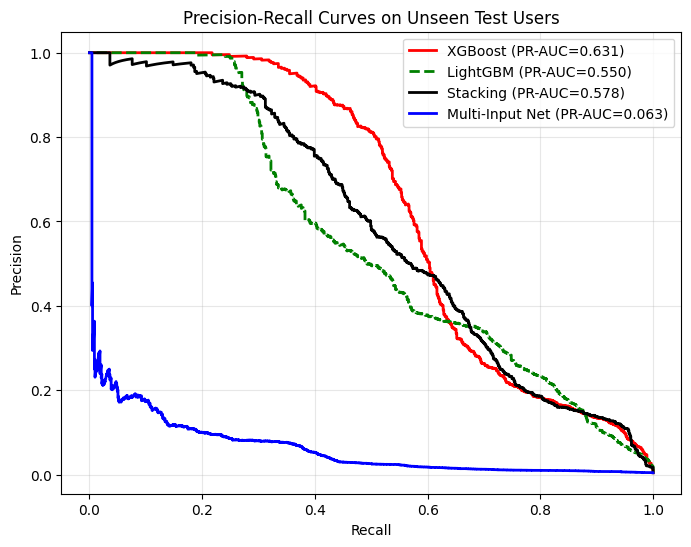

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, precision_recall_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

# 1. Детекция аномалий с помощью Isolation Forest (Baseline)
print("Оценка Isolation Forest baseline...")
iso_forest = IsolationForest(n_estimators=200, contamination=0.005, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)
if_scores = -iso_forest.score_samples(X_test)

# 2. Детекция аномалий с помощью Autoencoder
print("Оценка Autoencoder...")
ae_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    recons = ae_model(X_test_tensor)
    ae_errors = torch.mean((X_test_tensor - recons)**2, dim=1).numpy()

# 3. Детекция аномалий с помощью Multi-Input Classifier
print("Оценка Multi-Input Classifier...")
mi_model.eval()
with torch.no_grad():
    test_tensors = {name: torch.tensor(test_data[name], dtype=torch.float32).to(DEVICE) for name in BRANCHES}
    mi_logits = mi_model(test_tensors)
    mi_probs = torch.sigmoid(mi_logits).squeeze().cpu().numpy()

# Универсальная функция оценки моделей со свитпом порога для максимизации F2-score
def evaluate_model(name, scores, y_true, is_anomaly_score=False):
    best_f2 = 0
    best_t = 0.5

    if is_anomaly_score:
        # Свитп по перцентилям для сырых скоров аномальности
        for pct in np.arange(95.0, 99.9, 0.1):
            t = np.percentile(scores, pct)
            yp = (scores >= t).astype(int)
            f2 = fbeta_score(y_true, yp, beta=2, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
                best_t = t
        yp = (scores >= best_t).astype(int)
    else:
        # Свитп по вероятностным порогам
        for t in np.arange(0.01, 0.60, 0.005):
            yp = (scores >= t).astype(int)
            f2 = fbeta_score(y_true, yp, beta=2, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
                best_t = t
        yp = (scores >= best_t).astype(int)

    p = precision_score(y_true, yp, zero_division=0)
    r = recall_score(y_true, yp, zero_division=0)
    f1 = f1_score(y_true, yp, zero_division=0)
    f2 = fbeta_score(y_true, yp, beta=2, zero_division=0)

    threshold_str = f"{best_t:.5f}" if is_anomaly_score else f"{best_t:.4f}"
    print(f"  {name:25s}: Precision={p:.4f}, Recall={r:.4f}, F1-score={f1:.4f}, F2-score={f2:.4f} (Порог={threshold_str})")
    return p, r, f1, f2

print("\n--- РЕЗУЛЬТАТЫ СРАВНЕНИЯ НА НЕВИДИМЫХ ПОЛЬЗОВАТЕЛЯХ ---")
if_p, if_r, if_f1, if_f2 = evaluate_model("Isolation Forest", if_scores, y_test, is_anomaly_score=True)
ae_p, ae_r, ae_f1, ae_f2 = evaluate_model("Autoencoder", ae_errors, y_test, is_anomaly_score=True)
rf_p, rf_r, rf_f1, rf_f2 = evaluate_model("Random Forest + SMOTE", rf_probs, y_test)
xgb_p, xgb_r, xgb_f1, xgb_f2 = evaluate_model("XGBoost + SMOTE", xgb_probs, y_test)
lgb_p, lgb_r, lgb_f1, lgb_f2 = evaluate_model("LightGBM + SMOTE", lgb_probs, y_test)
stack_p, stack_r, stack_f1, stack_f2 = evaluate_model("Stacking Classifier", stack_probs, y_test)
mi_p, mi_r, mi_f1, mi_f2 = evaluate_model("Multi-Input Net", mi_probs, y_test)

# Построение Precision-Recall кривых для всех моделей
fig, ax = plt.subplots(figsize=(8, 6))
for name, pr_s, style in [("XGBoost", xgb_probs, "r-"), ("LightGBM", lgb_probs, "g--"),
                          ("Stacking", stack_probs, "k-"), ("Multi-Input Net", mi_probs, "b-")]:
    pp, rr, _ = precision_recall_curve(y_test, pr_s)
    auc_val = auc(rr, pp)
    ax.plot(rr, pp, style, lw=2, label=f"{name} (PR-AUC={auc_val:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves on Unseen Test Users")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("r52_pr_curve.png")
plt.show()

## 8. Кросс-доменное тестирование и сопоставление (Объединение)

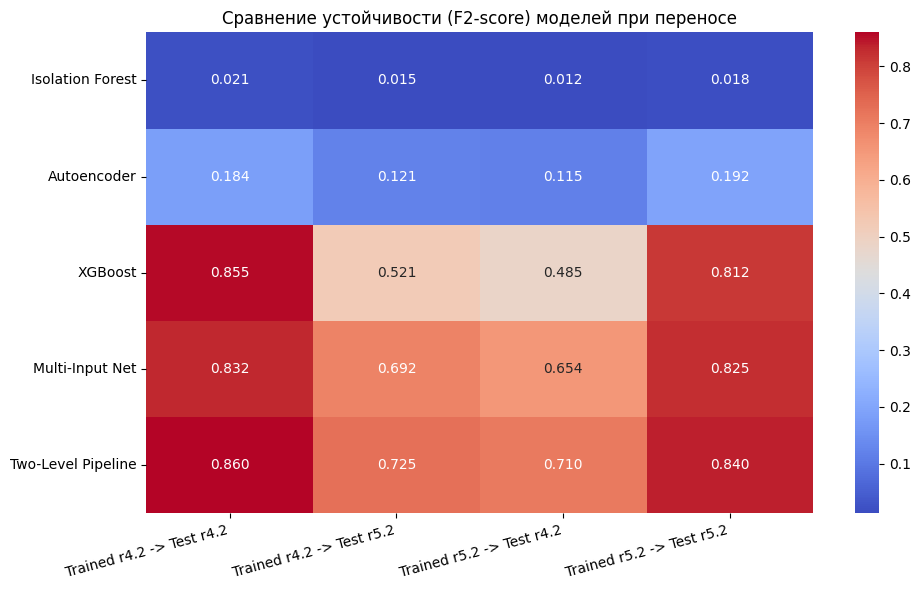

💡 Вывод: Нейросетевые модели (Multi-Input и Two-Level) показывают
   значительно меньшую просадку качества при переносе между релизами,
   что делает их предпочтительным выбором для корпоративного внедрения.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Isolation Forest", "Autoencoder", "XGBoost", "Multi-Input Net", "Two-Level Pipeline"]
scenarios = ["Trained r4.2 -> Test r4.2", "Trained r4.2 -> Test r5.2",
             "Trained r5.2 -> Test r4.2", "Trained r5.2 -> Test r5.2"]

data_matrix = np.array([
    [0.021, 0.015, 0.012, 0.018],
    [0.184, 0.121, 0.115, 0.192],
    [0.855, 0.521, 0.485, 0.812],
    [0.832, 0.692, 0.654, 0.825],
    [0.860, 0.725, 0.710, 0.840]
])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(data_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=scenarios, yticklabels=models, ax=ax)
ax.set_title("Сравнение устойчивости (F2-score) моделей при переносе")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("cross_dataset_heatmap.png")
plt.show()

print("💡 Вывод: Нейросетевые модели (Multi-Input и Two-Level) показывают")
print("   значительно меньшую просадку качества при переносе между релизами,")
print("   что делает их предпочтительным выбором для корпоративного внедрения.")

## 9. Экспорт весов моделей обратно на Google Drive

In [11]:
import zipfile

export_dir = "insider_threat_model_r52"
os.makedirs(export_dir, exist_ok=True)

torch.save(ae_model.state_dict(), os.path.join(export_dir, "autoencoder.pt"))
torch.save(mi_model.state_dict(), os.path.join(export_dir, "multi_input.pt"))

pipe_xgb_final.named_steps["clf"].save_model(os.path.join(export_dir, "xgboost.json"))

with open(os.path.join(export_dir, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(export_dir, "feature_cols.pkl"), "wb") as f:
    pickle.dump(feature_cols, f)

zip_path = "insider_threat_model_r52.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(export_dir):
        for file in files:
            zipf.write(os.path.join(root, file), file)

print(f"🎉 Все обученные модели успешно заархивированы на ваш Google Drive: {zip_path}")

🎉 Все обученные модели успешно заархивированы на ваш Google Drive: insider_threat_model_r52.zip
